# Point clouds: reconstructing a missing patch

Inspired by **3D Scan Patch for Printing**, Toyoshi:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#3d-scan-patch-for-printing) ·
[creator post](https://x.com/toyoshi/status/2098690472193695756).

**Learn:** distinguish measured points, a fitted surface and unseen geometry.
**Predict:** can a smooth fit look convincing while missing a real bump?
Our synthetic scan has known ground truth, allowing an honest check inside the missing region.
This is surface fitting, not watertight mesh repair or a printable engineering part.


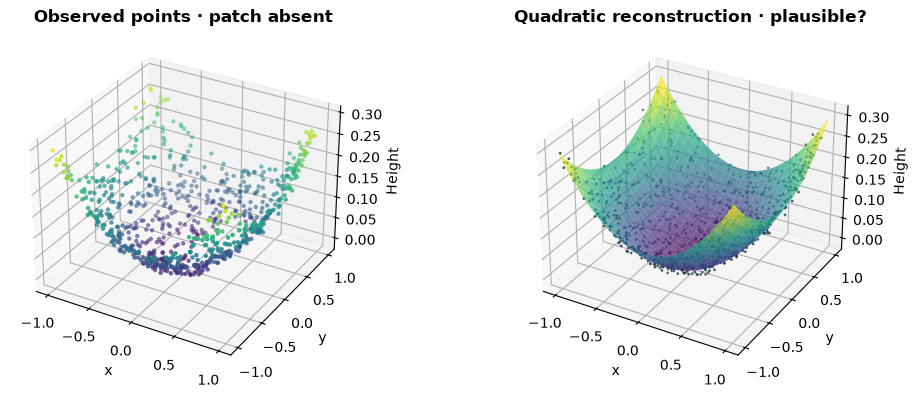

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style
style()
rng = np.random.default_rng(31)
def truth(x,y):
    return .18*x*x + .12*y*y + .25*np.exp(-((x-.25)**2+(y-.15)**2)/.035)
def design(x,y):
    return np.column_stack([np.ones(np.size(x)),np.ravel(x),np.ravel(y),np.ravel(x*x),np.ravel(x*y),np.ravel(y*y)])
xy = rng.uniform(-1,1,(850,2))
visible = (xy[:,0]-.25)**2+(xy[:,1]-.15)**2 > .33**2
samples = xy[visible]
z = truth(*samples.T) + rng.normal(0,.008,len(samples))
coeff,_,_,_ = np.linalg.lstsq(design(*samples.T),z,rcond=None)
X,Y = np.meshgrid(np.linspace(-1,1,55),np.linspace(-1,1,55))
Z = truth(X,Y)
fit = (design(X,Y) @ coeff).reshape(X.shape)
missing = (X-.25)**2+(Y-.15)**2 <= .33**2
fig = plt.figure(figsize=(12,4.5))
ax = fig.add_subplot(121,projection='3d')
ax.scatter(*samples.T,z,c=z,cmap='viridis',s=5)
ax.set(title='Observed points · patch absent',xlabel='x',ylabel='y',zlabel='Height')
ax = fig.add_subplot(122,projection='3d')
ax.plot_surface(X,Y,fit,cmap='viridis',alpha=.7)
ax.scatter(*samples.T,z,color='#153446',s=1)
ax.set(title='Quadratic reconstruction · plausible?',xlabel='x',ylabel='y',zlabel='Height')
plt.show()


A least-squares fit minimizes residuals on the points it has seen. It cannot recover a feature
hidden entirely inside a hole without additional information. A smooth appearance is a prior,
not proof of accuracy. Here we deliberately use a quadratic model that cannot represent the bump.


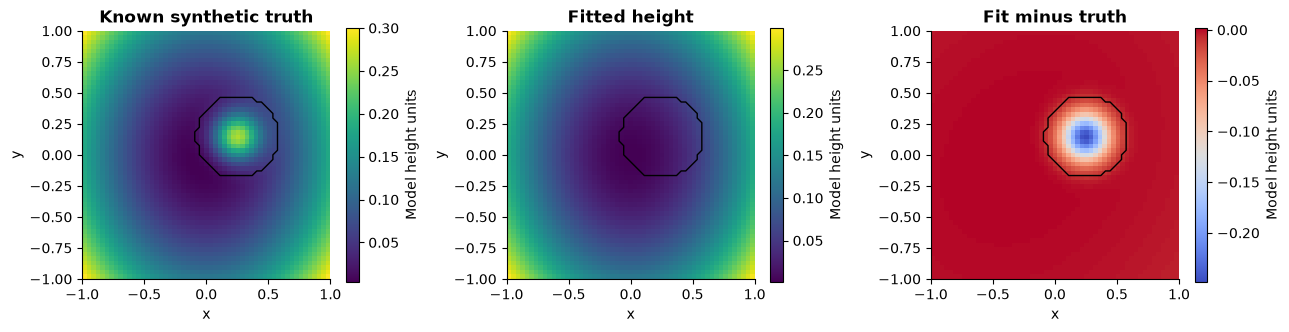

Observed-point RMSE: 0.0081; hidden-patch RMSE: 0.0995


In [2]:
error = fit-Z
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax,data,title in zip(axes,[Z,fit,error],['Known synthetic truth','Fitted height','Fit minus truth']):
    im = ax.imshow(data,origin='lower',extent=(-1,1,-1,1),cmap='coolwarm' if title=='Fit minus truth' else 'viridis')
    ax.contour(X,Y,missing,levels=[.5],colors='black',linewidths=1)
    ax.set(title=title,xlabel='x',ylabel='y')
    fig.colorbar(im,ax=ax,shrink=.7,label='Model height units')
fig.tight_layout()
plt.show()
observed_rmse = np.sqrt(np.mean((design(*samples.T)@coeff-z)**2))
hole_rmse = np.sqrt(np.mean(error[missing]**2))
print(f'Observed-point RMSE: {observed_rmse:.4f}; hidden-patch RMSE: {hole_rmse:.4f}')
assert np.isfinite(coeff).all() and hole_rmse > observed_rmse


**Read the result:** the black ring marks the withheld region. Low error on observations coexists
with high error in the hole. This is why reconstruction needs uncertainty and held-out validation.
**Experiment:** move the hole away from the bump, or increase its radius. Compare both error measures.
**Transfer:** when real scans lack ground truth, use extra views or independent measurements.
